# META (Multiple Equivalent Threshold Alarms)
* META is an anamoly detection algorithm from the good folks at RSL
* It is inspired by the Bonferroni correction for testing of multiple hypothesis
* More specifically, using $n$ observations with $k$ thresholds, we can view the composite hypothesis as:$$\cup_{i=1}^k\:\left[\mathcal{H}_i: X_{(n-i+1)} > m_i\right]$$
    * $X_{(i)}$ is the $i^{th}$ order statistic
    * $m_1 \ge ...\ge m_k$'s are the thresholds
* Under the null hypothesis, given significance level $\alpha$ we can calculate our thresholds using the probability integral transform and the property $$U\sim\mathcal{U}(0,1)\rightarrow U_{(n-i+1)}\sim\mathcal{B}(n-i+1,1)$$
* This notebook contains few examples in python

In [328]:
from typing import Union, Sequence, Protocol, Any
import numpy as np
import scipy.stats as stats
from numpy.typing import ArrayLike, NDArray
import matplotlib.pyplot as plt
import seaborn as sns
from src.random_variables import *
import warnings
from src.meta import *

N = 100000
m = 11
seed = 42

n = 5
k = 2
t = 3600
runs = 100
alpha = 1/3600.


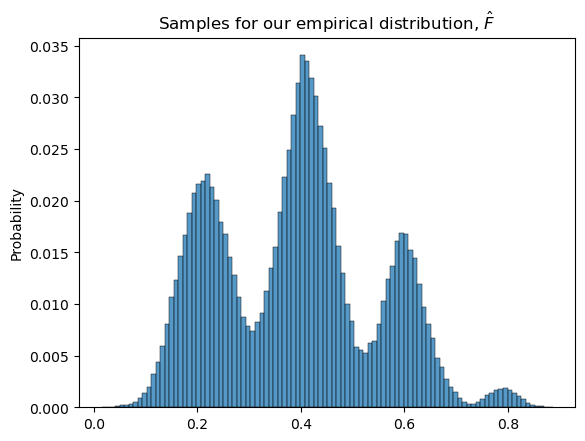

In [331]:

means = stats.norm.rvs(loc=0, scale=1, size = m, random_state=seed)
probs = stats.beta.rvs(a=0.1, b=0.1, size = m, random_state=seed)
data = stats.multinomial.rvs(m-1, probs/probs.sum(), size=N, random_state=seed)

means = np.array([means[d] for d in data])**2
data = (stats.norm(means,0.1).rvs(random_state=seed)).mean(axis=-1)

sns.histplot(data, bins=100, kde=False, stat = 'probability', label = 'x')
# plt.xlim([0, 3])
plt.title('Samples for our empirical distribution, ' +r'$\hat{F}$')
plt.show()

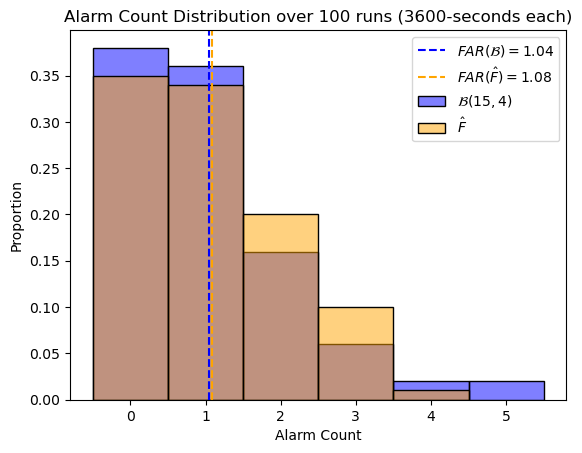

In [330]:
b_sim = stats.beta(15,4).rvs(size = (runs, n, t))
b_sim = stats.beta(15,4).cdf(b_sim)

F = ERV(stats.ecdf(data))
f_sim = F.rvs(size = (runs, n, t))
f_sim = F.cdf(f_sim)

_, b_alarm = meta(b_sim, n, k, alpha)
_, f_alarm = meta(f_sim, n, k, alpha)

def plotter():
    # Sum the alarms across runs
    b_sum = b_alarm.sum(axis = 0)
    f_sum = f_alarm.sum(axis = 0)

    # Create bins so that the bars are centered on integer values
    bins_b = np.arange(b_sum.min() - 0.5, b_sum.max() + 1.5, 1)
    bins_f = np.arange(f_sum.min() - 0.5, f_sum.max() + 1.5, 1)

    sns.histplot(b_sum, bins=bins_b, color='blue', label= r'$\mathcal{B}(15,4)$', kde = False, stat = 'probability', alpha=0.5)
    plt.axvline(b_sum.mean(), color = 'blue', linestyle = '--', label = r'$FAR(\mathcal{B}) = $' + f'{b_sum.mean():.2f}')

    sns.histplot(f_sum, bins=bins_f, color='orange', label=r'$\hat{F}$', kde = False, stat = 'probability', alpha=0.5)
    plt.axvline(f_sum.mean(), linestyle = '--', color = 'orange', label = r'$FAR(\hat{F})= $' + f'{f_sum.mean():.2f}')

    plt.xticks(np.arange(min(b_sum.min(), f_sum.min()), max(b_sum.max(), f_sum.max()) + 1, 1))
    plt.xlabel('Alarm Count')
    plt.ylabel('Proportion')
    plt.title(f'Alarm Count Distribution over {runs} runs ({t}-seconds each)')
    plt.legend()
    plt.show()
plotter()